In [10]:
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from highlight_text import ax_text, fig_text
from drawarrow import ax_arrow, fig_arrow
from pyfonts import load_google_font
from pypalettes import load_cmap

import re
import os

In [3]:
# Data
data_path = os.path.join("..", "data", "IPL Auction (2013-2026).xlsx")
data = pd.read_excel(data_path)

data["Value"] = data["Value"].apply(lambda x: float(re.sub(r"[?,/]", "", x)) if isinstance(x, str) else float(x))

df = data.copy()

df["Value Cr"] = df["Value"] / 10000000
df["Value Lakh"] = df["Value"] / 100000

In [4]:
years = sorted(df["Year"].unique())

base_year = years[0]
base_year_max = df.loc[df["Year"] == base_year, "Value"].max()

for y in years:
    sub_df = df.loc[df["Year"] == y].copy()

    # Min
    min_idx = sub_df["Value"].idxmin()
    min_auction = sub_df.loc[min_idx, "Value"]
    min_player = sub_df.loc[min_idx, "Player"]
    min_player_role = sub_df.loc[min_idx, "Role"]
    min_player_team = sub_df.loc[min_idx, "Team"]

    # Max
    max_idx = sub_df["Value"].idxmax()
    max_auction = sub_df.loc[max_idx, "Value"]
    max_player = sub_df.loc[max_idx, "Player"]
    max_player_role = sub_df.loc[max_idx, "Role"]
    max_player_team = sub_df.loc[max_idx, "Team"]

    # Median (pick closest player to median)
    median_auction = sub_df["Value"].median()
    median_idx = (sub_df["Value"] - median_auction).abs().idxmin()
    median_player = sub_df.loc[median_idx, "Player"]
    median_player_role = sub_df.loc[median_idx, "Role"]
    median_player_team = sub_df.loc[median_idx, "Team"]
    median_player_value = sub_df.loc[median_idx, "Value"]  # <-- closest player's actual value

    print(f"Year - {y}")
    print(f"Min. Auction    -> {min_player}, {min_player_role}, {min_player_team} -> INR {min_auction:.0f}")
    print(f"Max. Auction    -> {max_player}, {max_player_role}, {max_player_team} -> INR {max_auction:.0f}")
    print(f"Median (closest)-> {median_player}, {median_player_role}, {median_player_team} -> INR {median_player_value:.0f} (median={median_auction:.0f})")

    if y != base_year:
        print(f"{(max_auction / base_year_max):.2f}x vs. Max. Auction value in Year {base_year}")

    print("--" * 10)

Year - 2013
Min. Auction    -> Ben Laughlin, Bowler, Chennai Super Kings -> INR 20000
Max. Auction    -> Glenn Maxwell, All-Rounder, Mumbai Indians -> INR 1000000
Median (closest)-> Luke Pomersbach, Batsman, Kings XI Punjab -> INR 300000 (median=300000)
--------------------
Year - 2014
Min. Auction    -> Vijay Shankar, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, All-Rounder, Royal Challengers Bengaluru -> INR 140000000
Median (closest)-> Ben Hilfenhaus, Bowler, Chennai Super Kings -> INR 10000000 (median=10000000)
140.00x vs. Max. Auction value in Year 2013
--------------------
Year - 2015
Min. Auction    -> Pratyush Singh, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, Batsman, Delhi Daredevils -> INR 160000000
Median (closest)-> Rahul Sharma, Bowler, Chennai Super Kings -> INR 3000000 (median=3000000)
160.00x vs. Max. Auction value in Year 2013
--------------------
Year - 2016
Min. Auction    -> Chama Milind, Bowl

In [5]:
year_start = 2013
year_end = 2025

df2 = df[(df["Year"]>=year_start) & (df["Year"]<=year_end)]

In [6]:

df_group = df2.groupby(by=["Year"], as_index=False).agg(
    median_val = ("Value Lakh", "median"),
    mean_val = ("Value Lakh", "mean"),
    min_val = ("Value Lakh", "min"),
    max_val = ("Value Lakh", "max"),
    total_val = ("Value Lakh", "sum"),
    n_players = ("Value Lakh", "size")
)

df_group["per_player_val"] = df_group["total_val"]/df_group["n_players"]

df_group

,Year,median_val,mean_val,min_val,max_val,total_val,n_players,per_player_val
0,2013,3.0,3.212162,0.2,10.0,118.85,37,3.212162
1,2014,100.0,170.519481,10.0,1400.0,26260.00,154,170.519481
2,2015,30.0,130.746269,10.0,1600.0,8760.00,67,130.746269
3,2016,50.0,144.680851,10.0,950.0,13600.00,94,144.680851
4,2017,40.0,138.106061,10.0,1450.0,9115.00,66,138.106061
5,2018,170.0,255.443787,20.0,1250.0,43170.00,169,255.443787
6,2019,75.0,178.000000,20.0,840.0,10680.00,60,178.000000
7,2020,90.0,226.290323,20.0,1550.0,14030.00,62,226.290323
8,2021,50.0,254.912281,20.0,1625.0,14530.00,57,254.912281
9,2022,105.0,270.441176,20.0,1525.0,55170.00,204,270.441176


In [11]:
# Fonts

rb_reg = load_google_font("Roboto Condensed")
rb_it = load_google_font("Roboto Condensed", italic=True)
rb_b = load_google_font("Roboto Condensed", weight=400)
rb_thin = load_google_font("Roboto Condensed", weight=100)

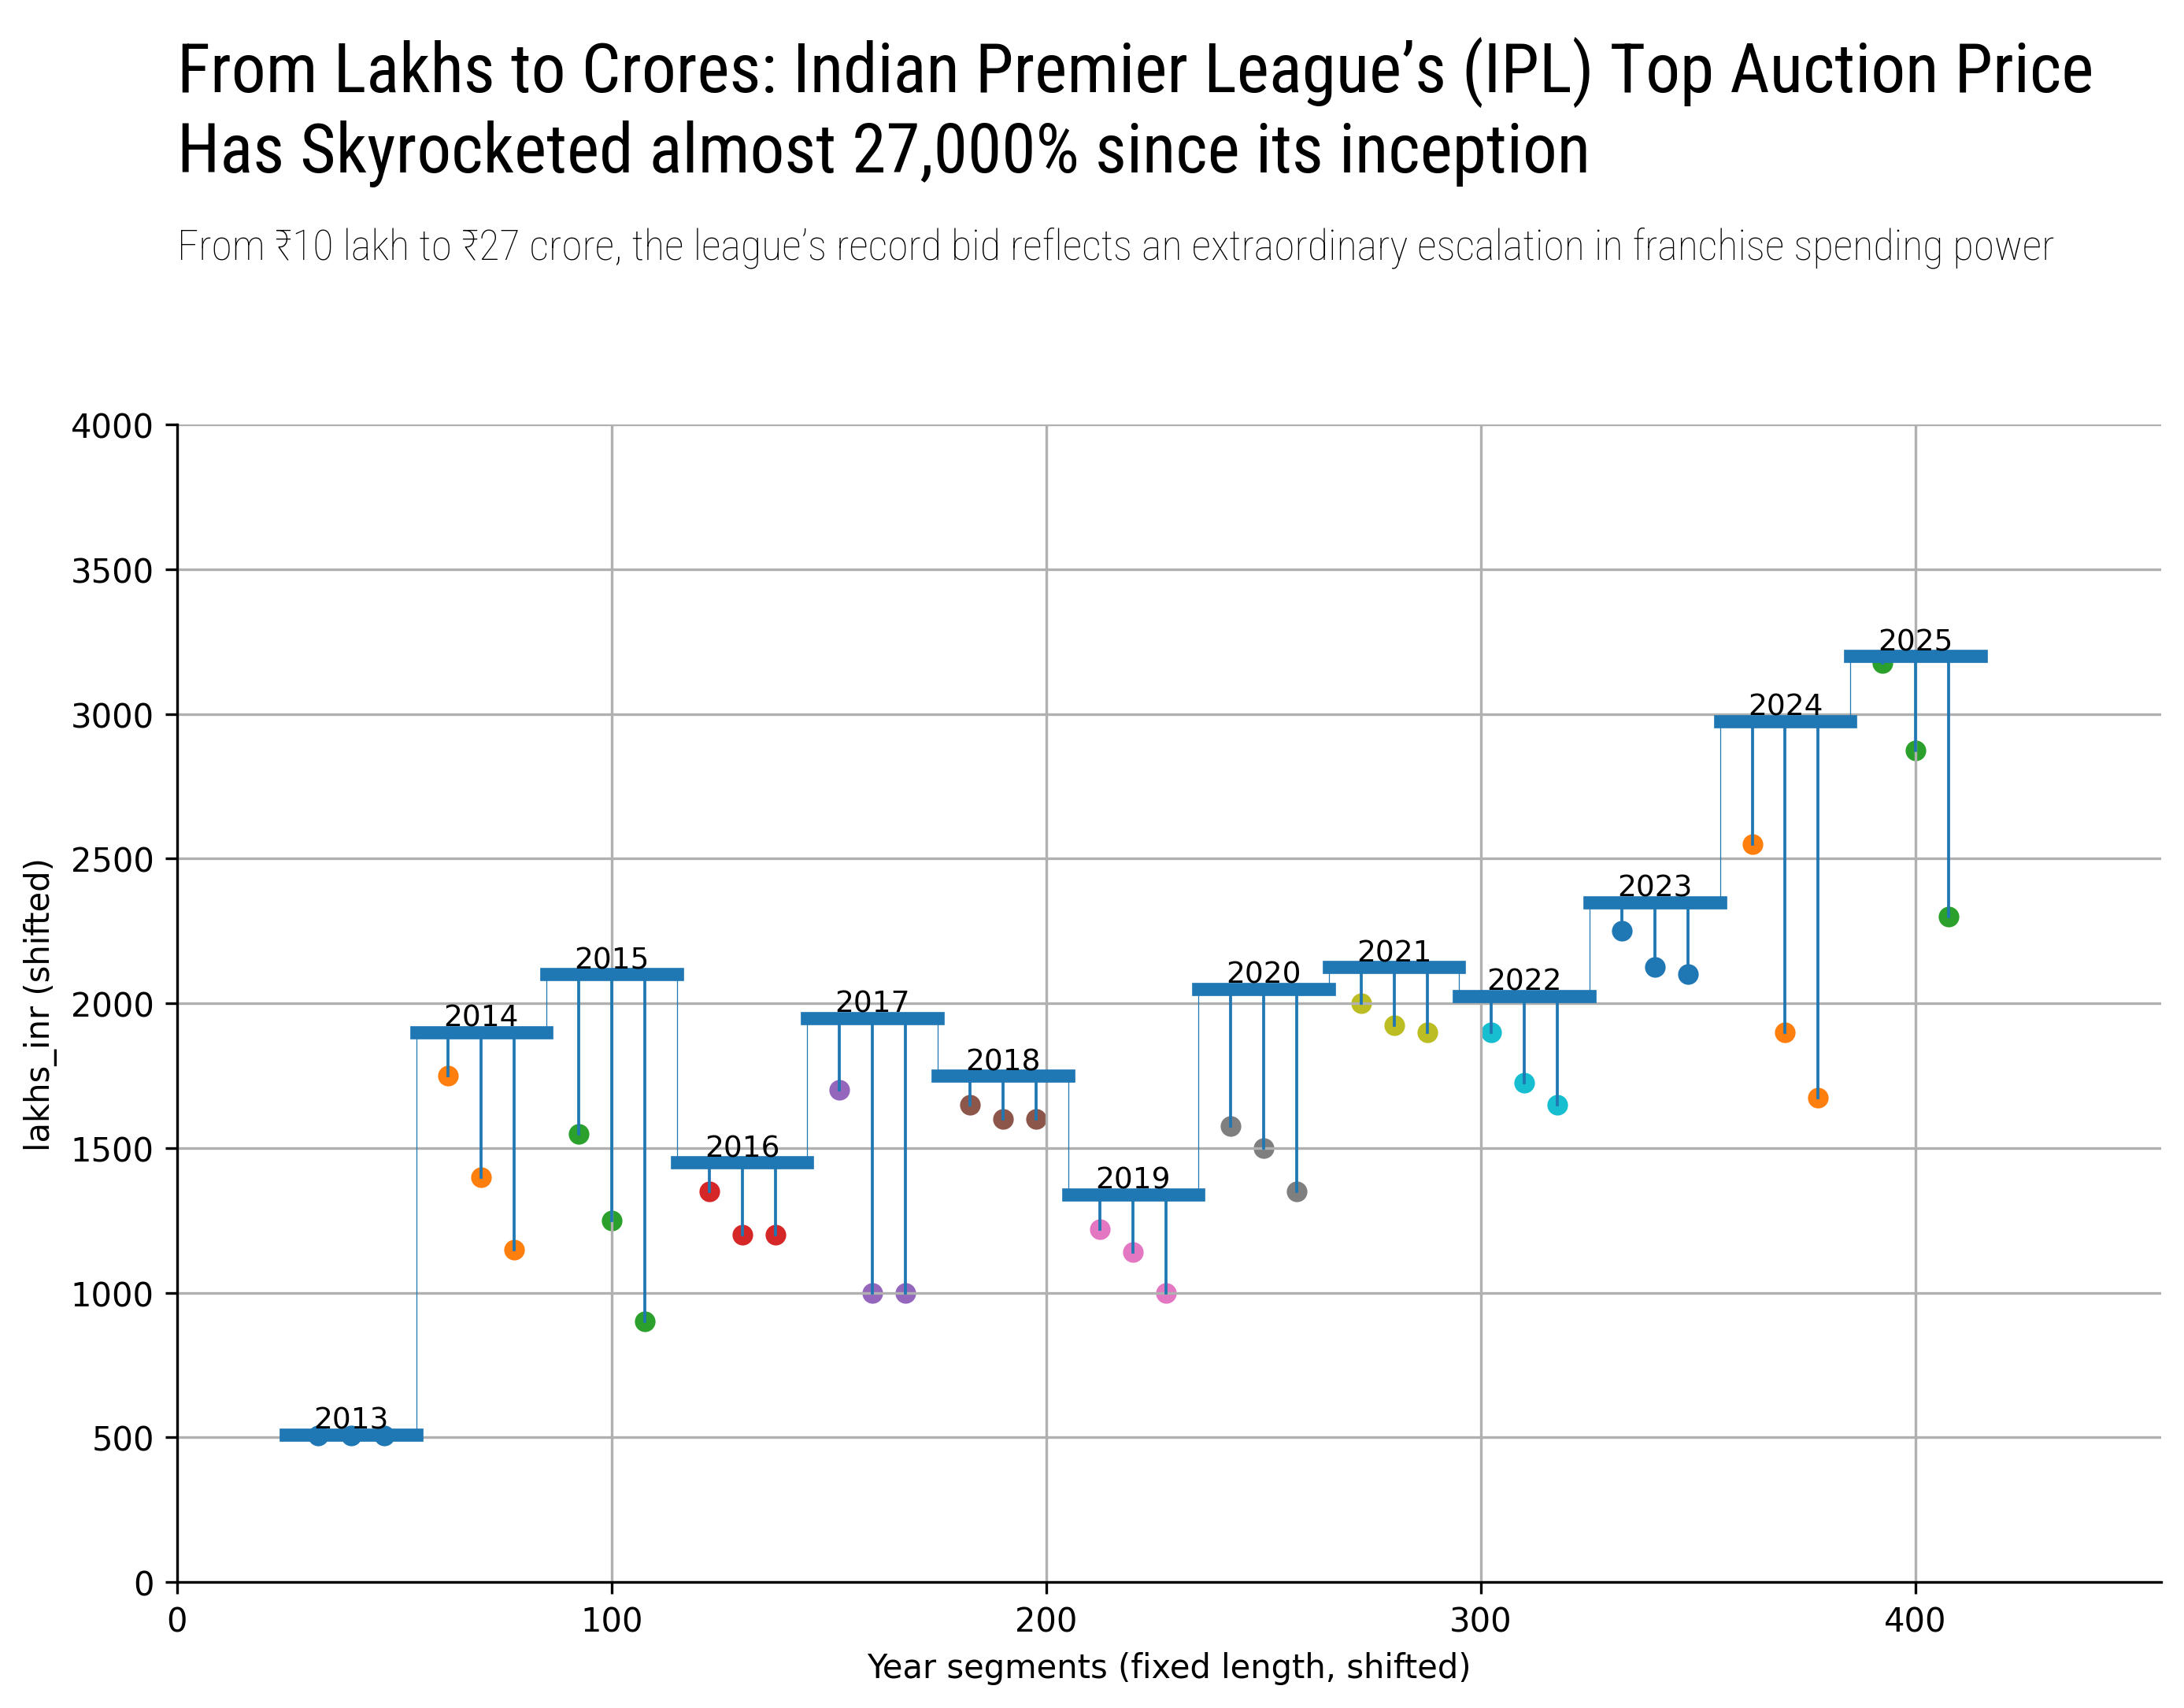

In [26]:
line_thickness = 4
vertical_connector_thickness = 0.3
y_offset = 500       # shifts everything UP/DOWN (add to every y)
x_offset = 25        # shifts everything RIGHT/LEFT (add to every x)

line_length = 30     # SAME length for every thick segment (in x-units)
n_top = 3            # plot top N values AFTER the max (i.e., 2nd..(N+1)th)

stem_thickness = 0.9
dot_size = 28
pad_frac = 0.12      # padding inside segment for lollipop x positions

# spacing between year segments (since all same length)
gap = 0

# ---------------------------
def even_slot_midpoints(x_start: float, x_end: float, n_points: int, pad_frac: float = 0.12) -> np.ndarray:
    """Evenly place n_points inside [x_start, x_end] using slot midpoints, with padding."""
    if n_points <= 0:
        return np.array([])

    seg_len = x_end - x_start
    pad = seg_len * pad_frac
    x_left = x_start + pad
    x_right = x_end - pad

    if x_right <= x_left:
        return np.full(n_points, (x_start + x_end) / 2)

    slot_edges = np.linspace(x_left, x_right, n_points + 1)
    return (slot_edges[:-1] + slot_edges[1:]) / 2

# ---------------------------
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

fig.subplots_adjust(left=0.15, right=0.85, top=0.75, bottom=0.05)

title = "From Lakhs to Crores: Indian Premier League’s (IPL) Top Auction Price\nHas Skyrocketed almost 27,000% since its inception"
subtitle = "From ₹10 lakh to ₹27 crore, the league’s record bid reflects an extraordinary escalation in franchise spending power"

# Title & Subtitle
fig_text(s=title, x=0.15, y=0.985, ha="left",
         size=21, font=rb_b, color="black")

fig_text(s=subtitle, x=0.15, y=.87, ha="left",
         size=13, font=rb_thin, color="black")

# fig_text(s="Data: USFDA Food Database", x=0.15, y=.01, ha="left",
#          size=11, font=rb_thin, color=color_hex["charcoal"])


x_cursor = 0
prev_start_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = int(r["Year"])

    # thick line is at MAX value for that year (shifted)
    y_base = float(r["max_val"]) + y_offset

    # SAME segment length for each year
    x_start_base = x_cursor
    x_end_base = x_cursor + line_length

    # apply x shift
    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick horizontal max line
    ax.add_line(Line2D([x_start, x_end], [y_base, y_base], linewidth=line_thickness))

    # thin connector (start-to-start)
    if prev_start_x is not None:
        ax.add_line(Line2D([x_start, x_start], [prev_y, y_base], linewidth=vertical_connector_thickness))

    # year label
    ax.text((x_start + x_end) / 2, y_base, str(year), ha="center", va="bottom", fontsize=9)

    # ---------------------------
    # LOLLIPOPS: top N values AFTER the max (i.e., exclude the maximum itself)
    year_vals = df2.loc[df2["Year"] == year, "Value Lakh"].to_numpy(dtype=float)

    if year_vals.size > 0:
        # sort descending
        sorted_desc = np.sort(year_vals)[::-1]

        # drop ALL occurrences of the max value (so if max repeats, none of them become lollipops)
        max_val = sorted_desc[0]
        after_max = sorted_desc[sorted_desc < max_val]

        # take next top N
        top_vals = after_max[:n_top]

        # equispaced positions across this thick line
        x_pts = even_slot_midpoints(x_start, x_end, top_vals.size, pad_frac=pad_frac)
        y_tips = top_vals + y_offset

        # stems + heads
        for xi, yi in zip(x_pts, y_tips):
            ax.add_line(Line2D([xi, xi], [y_base, yi], linewidth=stem_thickness))
        ax.scatter(x_pts, y_tips, s=dot_size)

    # ---------------------------
    prev_start_x = x_start
    prev_y = y_base

    # advance cursor in base space (fixed length + gap)
    x_cursor = x_end_base + gap

# axis limits
y_max = max(df_group["max_val"].max(), df2["Value Lakh"].max()) + y_offset
ax.set_xlim(0, (x_offset + x_cursor) * 1.1)
ax.set_ylim(0, y_max * 1.25)

ax.set_xlabel("Year segments (fixed length, shifted)")
ax.set_ylabel("lakhs_inr (shifted)")
ax.spines[["top", "right"]].set_visible(False)

ax.grid()

plt.show()